In [24]:
import glob
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f1500w": "/orange/adamginsburg/jwst/w51/F1500W/pipeline/jw06151-o002_t001_miri_f1500w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}



In [ ]:
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import numpy as np
from regions import Regions
from astropy.nddata import Cutout2D
import astropy.units as u
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from astropy.table import Table
# Load region from DS9 region file
region_test = Regions.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalog_test.reg')[0]
center_coord = region_test.center

filters = ['f140m', 'f187n', 'f210m', 'f360m', 'f405n', 'f480m']



nrca_catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/basic_nrca_indivexp_photometry_tables_merged.fits')
nrcb_catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/basic_nrcb_indivexp_photometry_tables_merged.fits')


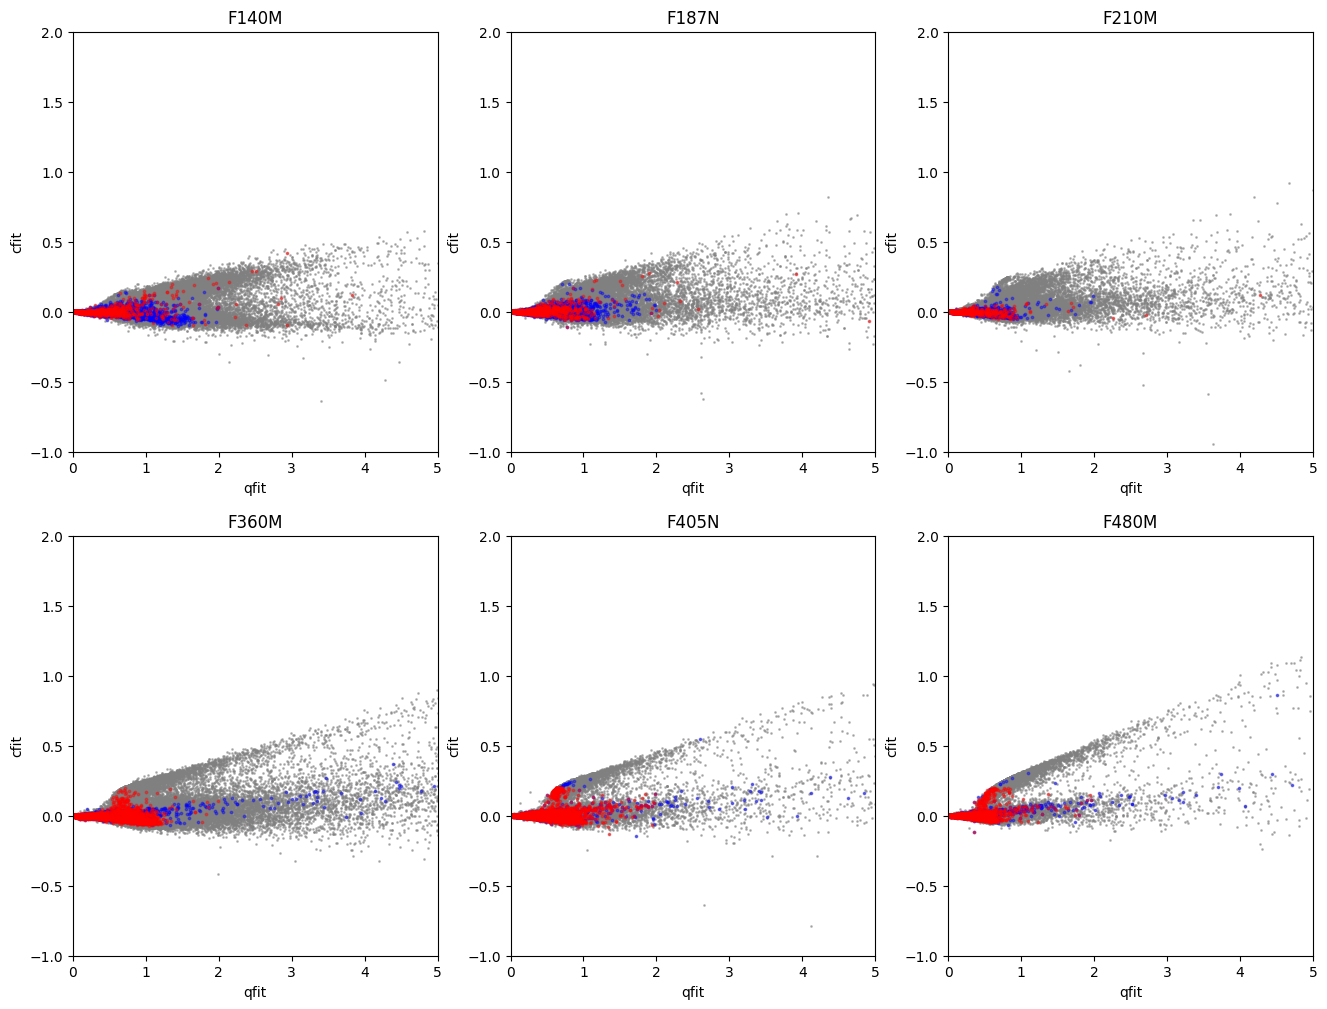

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 12))
axes = axes.flatten()

index_shortwav = ((nrca_catalog['qfit_f140m']<2) &
                (nrca_catalog['qfit_f162m']<2) &
                (nrca_catalog['qfit_f182m']<2) &
                (nrca_catalog['qfit_f187n']<2) &
                (nrca_catalog['qfit_f210m']<2) &
                (nrca_catalog['cfit_f140m']<0.2) &
                (nrca_catalog['cfit_f162m']<0.2) &
                (nrca_catalog['cfit_f182m']<0.2) &
                (nrca_catalog['cfit_f187n']<0.2) &
                (nrca_catalog['cfit_f210m']<0.2) &
                (nrca_catalog['cfit_f140m']>-0.2) &
                (nrca_catalog['cfit_f162m']>-0.2) &
                (nrca_catalog['cfit_f182m']>-0.2) &
                (nrca_catalog['cfit_f187n']>-0.2) &
                (nrca_catalog['cfit_f210m']>-0.2)
               )
index_longwav = ((nrca_catalog['qfit_f335m']<2) &
                (nrca_catalog['qfit_f360m']<2) &
                (nrca_catalog['qfit_f405n']<2) &
                (nrca_catalog['qfit_f410m']<2) &
                (nrca_catalog['qfit_f480m']<2) &
                (nrca_catalog['cfit_f335m']<0.2) &
                (nrca_catalog['cfit_f360m']<0.2) &
                (nrca_catalog['cfit_f405n']<0.2) &
                (nrca_catalog['cfit_f410m']<0.2) &
                (nrca_catalog['cfit_f480m']<0.2) &
                (nrca_catalog['cfit_f335m']>-0.2) &
                (nrca_catalog['cfit_f360m']>-0.2) &
                (nrca_catalog['cfit_f405n']>-0.2) &
                (nrca_catalog['cfit_f410m']>-0.2) &
                (nrca_catalog['cfit_f480m']>-0.2)
               )


index = np.where((nrca_catalog['qfit_f140m']<2) &
                 (nrca_catalog['qfit_f187n']<2) &
                 (nrca_catalog['qfit_f210m']<2) &
                 (nrca_catalog['qfit_f360m']<2) &
                 (nrca_catalog['qfit_f405n']<2) &
                 (nrca_catalog['qfit_f480m']<2) &
                 (nrca_catalog['cfit_f140m']<0.2) &
                 (nrca_catalog['cfit_f187n']<0.2) &
                 (nrca_catalog['cfit_f210m']<0.2) &
                 (nrca_catalog['cfit_f360m']<0.2) &
                 (nrca_catalog['cfit_f405n']<0.2) &
                 (nrca_catalog['cfit_f480m']<0.2) &
                 (nrca_catalog['cfit_f140m']>-0.2) &
                 (nrca_catalog['cfit_f187n']>-0.2) &
                 (nrca_catalog['cfit_f210m']>-0.2) &
                 (nrca_catalog['cfit_f360m']>-0.2) &
                 (nrca_catalog['cfit_f405n']>-0.2) &
                 (nrca_catalog['cfit_f480m']>-0.2)
                )[0]
i

for i, filt in enumerate(filters):
    skycoord_ref = nrca_catalog['skycoord_ref']
    qfit = nrca_catalog[f'qfit_{filt}']
    cfit = nrca_catalog[f'cfit_{filt}']
    axes[i].scatter(qfit, cfit, s=1, c='gray', alpha=0.5)
    #axes[i].scatter(qfit[index_], cfit[index], s=1, c='red', alpha=0.5)
    axes[i].scatter(qfit[index_shortwav], cfit[index_shortwav], s=3, c='blue', alpha=0.4)
    axes[i].scatter(qfit[index_longwav], cfit[index_longwav], s=3, c='red', alpha=0.4)
    axes[i].set_title(f'{filt.upper()}')
    axes[i].set_xlabel('qfit')
    axes[i].set_ylabel('cfit')
    axes[i].set_xlim(0, 5)
    axes[i].set_ylim(-1,2)


Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


(array([2243.10965497, 1797.6599268 , 1805.13023719, ...,  791.03573308,
        907.95641466, 2080.68920744]), array([-347.14663979, -343.95283181, -346.85905398, ..., 3788.26840143,
       3789.56268971, 3819.70917449]))
[2243.10965497 1797.6599268  1805.13023719 ...  791.03573308  907.95641466
 2080.68920744]


Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


(array([2243.13279034, 1797.66768775, 1805.13825485, ...,  791.01037964,
        907.93509751, 2080.70838162]), array([-347.99422473, -344.80013064, -347.70645608, ..., 3787.56413265,
       3788.85841945, 3819.00548179]))
[2243.13279034 1797.66768775 1805.13825485 ...  791.01037964  907.93509751
 2080.70838162]


Set DATE-AVG to '2025-05-06T16:06:02.819' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


...

(array([1110.70256194,  889.59682237,  893.29278401, ...,  407.35427484,
        465.39863253, 1047.66510015]), array([-180.38741956, -176.9218905 , -178.39605637, ..., 1878.54266144,
       1878.69164576, 1888.70639634]))
[1110.70256194  889.59682237  893.29278401 ...  407.35427484  465.39863253
 1047.66510015]


Set DATE-AVG to '2025-05-06T13:24:26.757' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.021' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202550 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191894.941 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


(array([1110.29626642,  889.29450581,  892.98872828, ...,  407.28030261,
        465.29736469, 1047.29002562]), array([-180.8878355 , -177.42376757, -178.89724302, ..., 1877.07455736,
       1877.22342736, 1887.23302461]))
[1110.29626642  889.29450581  892.98872828 ...  407.28030261  465.29736469
 1047.29002562]


Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


(array([1110.49646329,  889.42613731,  893.12150643, ...,  407.2616224 ,
        465.29668377, 1047.46989959]), array([-181.05951084, -177.59445111, -179.06838231, ..., 1877.541085  ,
       1877.69002295, 1887.70294391]))
[1110.49646329  889.42613731  893.12150643 ...  407.2616224   465.29668377
 1047.46989959]


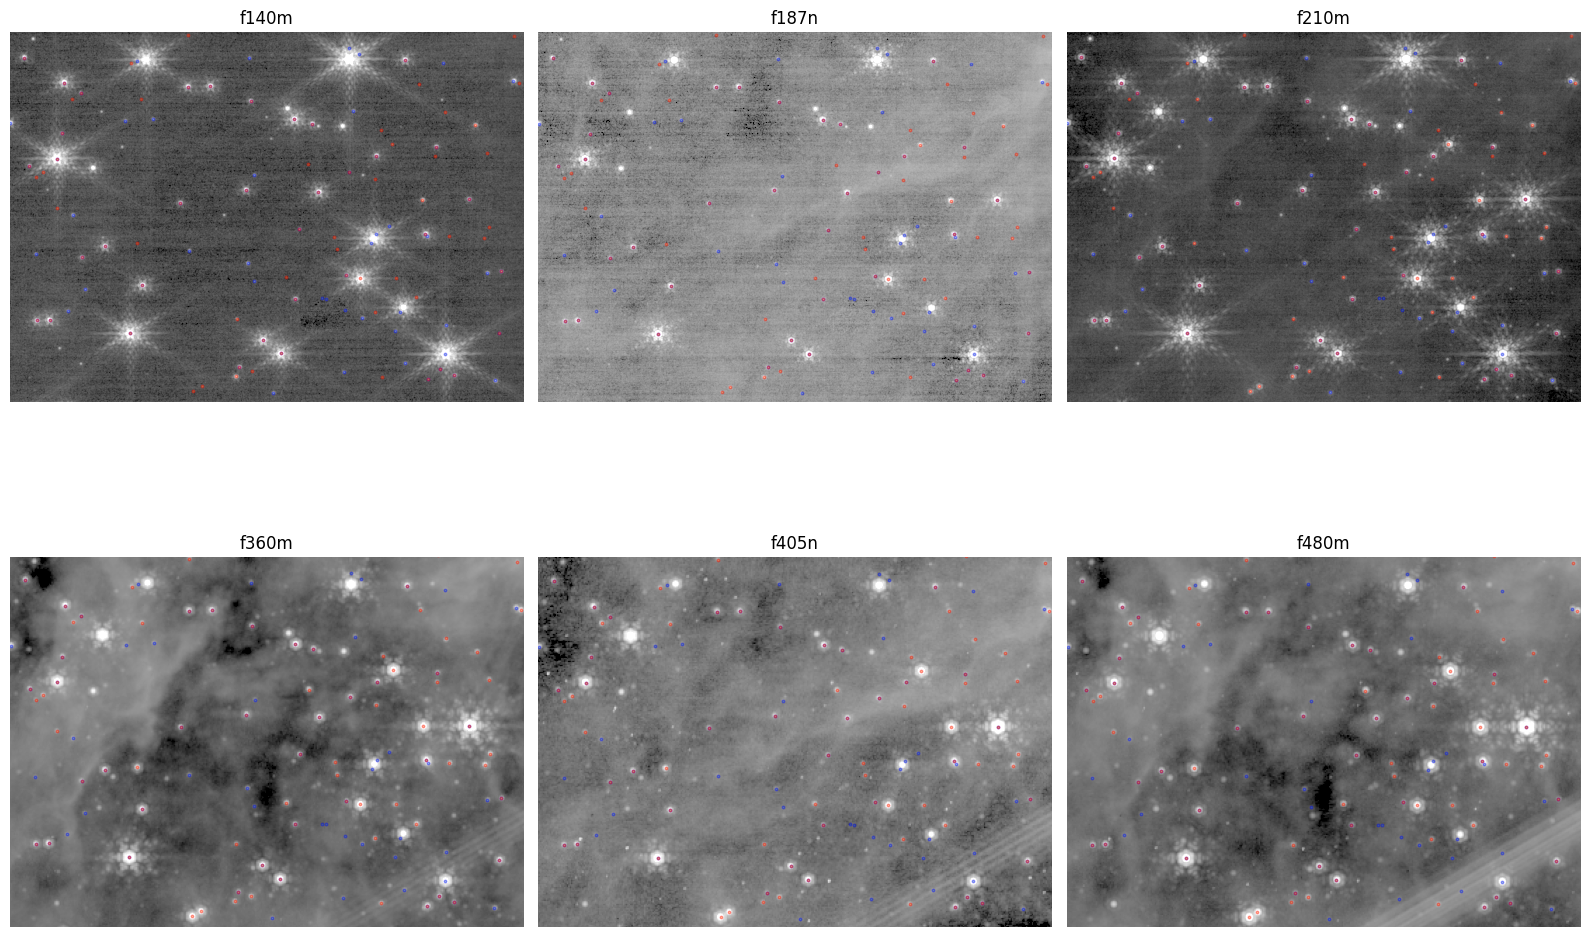

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 12))
axes = axes.flatten()
for i, filt in enumerate(filters):
    filename = image_filenames[filt]
    hdu = fits.open(filename)
    data = hdu[1].data if len(hdu) > 1 else hdu[0].data
    wcs = WCS(hdu[1].header if len(hdu) > 1 else hdu[0].header)
    cutout = Cutout2D(data, center_coord, (region_test.height, region_test.width), wcs=wcs)
    norm = simple_norm(cutout.data, 'log', percent=99.5)
    axes[i].imshow(cutout.data, origin='lower', cmap='gray', norm=norm)
    skycoord_ref = nrca_catalog['skycoord_ref']
    #convert skycoordinates to pixel coordinates in the cutout
    pixcoords = cutout.wcs.world_to_pixel(skycoord_ref)
    print(pixcoords)
    print(pixcoords[0])
    ra = pixcoords[0][index_shortwav]
    dec = pixcoords[1][index_shortwav]
    axes[i].scatter(ra, dec, s=3, edgecolor='blue', alpha=0.4)
    ra = pixcoords[0][index_longwav]
    dec = pixcoords[1][index_longwav]
    axes[i].scatter(ra, dec, s=3, edgecolor='red', alpha=0.4)
    #ra = pixcoords[0][index] --- IGNORE
    axes[i].set_title(filt)
    axes[i].axis('off')
    axes[i].set_xlim(cutout.xmin_cutout, cutout.xmax_cutout)
    axes[i].set_ylim(cutout.ymin_cutout, cutout.ymax_cutout)
    hdu.close()

plt.tight_layout()
plt.show()